# HOMER × Hodge 2019 — cortical layer marker validation

[Hodge et al. 2019, *Nature*](https://www.nature.com/articles/s41586-019-1506-7) showed that canonical layer-defining transcription factors maintain their layer-specific spatial expression across mouse and human cortex:

- **CUX1, CUX2, SATB2** → upper cortical layers (L2/3)
- **RORB** → granular layer 4
- **FEZF2** → infragranular L5
- **TBR1, FOXP2** → deep layers (L6)

**HOMER's claim under test:** if π maps mouse parcels to human parcels such that their connectivity neighborhoods + spatial position correspond correctly, then mouse parcels with high marker-X expression should map to human parcels with high marker-X expression — for each of the 7 layer markers.

**Why this is a clean test:** Hodge's data comes from Allen ISH (mouse) and AHBA microarray (human), which are different platforms from Beauchamp 2022's transcriptomic similarity dataset (HOMER's external benchmark). So agreement here is genuinely independent evidence about π's anatomical fidelity, with no leak.


## Setup

In [1]:
import os, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))

from homer.data import load_cached

pi = np.load(ROOT / 'outputs/coupling/pi_fc_plus_SC_with_all_packs.npy')
H, _ = load_cached('human', cache_dir=str(ROOT / 'outputs/anndata'))
print(f'HOMER π: {pi.shape}')

# Mouse Allen ISH (1864 × 61 curated genes)
mouse_expr = np.load(ROOT / 'data_external/mouse_genes.npy')
mouse_genes = pd.read_csv(ROOT / 'data_external/mouse_gene_list.csv')
print(f'Mouse Allen ISH: {mouse_expr.shape}, {len(mouse_genes)} genes')

# Human AHBA microarray (2094 × 15633 genes)
human_expr = np.load(ROOT / 'data_external/human_genes.npy')
human_genes = pd.read_csv(ROOT / 'data_external/human_gene_list.csv')
print(f'Human AHBA:      {human_expr.shape}, {len(human_genes)} genes')

# Fill NaNs with column means (parcels with no measurement in that gene)
for arr in [mouse_expr, human_expr]:
    cmean = np.nanmean(arr, axis=0)
    nz = np.where(np.isnan(arr))
    arr[nz] = np.take(cmean, nz[1])

HODGE_MARKERS = [
    ('Cux1',  'L2/3 upper'),  ('Cux2',  'L2/3 upper'),  ('Satb2', 'L2/3 upper'),
    ('Rorb',  'L4 granular'),
    ('Fezf2', 'L5 infragranular'),
    ('Tbr1',  'L6 deep'),     ('Foxp2', 'L6 deep'),
]
for m, l in HODGE_MARKERS:
    in_m = (mouse_genes['gene_symbol'].str.lower() == m.lower()).any()
    in_h = (human_genes['gene_symbol'].str.upper() == m.upper()).any()
    print(f'  {m:<8s} ({l:<18s}): mouse={in_m}, human={in_h}')


HOMER π: (1864, 2094)
Mouse Allen ISH: (1864, 61), 61 genes
Human AHBA:      (2094, 15633), 15633 genes


  Cux1     (L2/3 upper        ): mouse=True, human=True
  Cux2     (L2/3 upper        ): mouse=True, human=True
  Satb2    (L2/3 upper        ): mouse=True, human=True
  Rorb     (L4 granular       ): mouse=True, human=True
  Fezf2    (L5 infragranular  ): mouse=True, human=True
  Tbr1     (L6 deep           ): mouse=True, human=True
  Foxp2    (L6 deep           ): mouse=True, human=True


## Per-marker cross-species translation

For each Hodge marker, route its mouse spatial expression pattern through π and ask: does the predicted human spatial pattern correlate with the *observed* human expression pattern for that same gene?


In [2]:
def zscore(v):
    return (v - v.mean()) / (v.std() + 1e-9)

results = []
for m, layer in HODGE_MARKERS:
    m_idx = int(mouse_genes[mouse_genes['gene_symbol'].str.lower() == m.lower()].iloc[0].name)
    h_idx = int(human_genes[human_genes['gene_symbol'].str.upper() == m.upper()].iloc[0].name)
    m_vec = zscore(mouse_expr[:, m_idx])
    h_obs = zscore(human_expr[:, h_idx])
    pred_h = m_vec @ pi    # (2094,) — predicted human expression via HOMER
    r, p = pearsonr(pred_h, h_obs)
    results.append({'gene': m, 'layer': layer, 'r': r, 'p': p})
    print(f'  {m:<7s} ({layer:<18s}): Pearson r = {r:+.3f}  (analytical p = {p:.3f})')

mean_r = np.mean([r['r'] for r in results])
print(f"\nMean Pearson r across {len(results)} markers: {mean_r:+.3f}")


  Cux1    (L2/3 upper        ): Pearson r = -0.027  (analytical p = 0.224)
  Cux2    (L2/3 upper        ): Pearson r = -0.027  (analytical p = 0.224)
  Satb2   (L2/3 upper        ): Pearson r = +0.004  (analytical p = 0.860)
  Rorb    (L4 granular       ): Pearson r = +0.072  (analytical p = 0.001)
  Fezf2   (L5 infragranular  ): Pearson r = -0.011  (analytical p = 0.631)
  Tbr1    (L6 deep           ): Pearson r = -0.012  (analytical p = 0.597)
  Foxp2   (L6 deep           ): Pearson r = -0.055  (analytical p = 0.012)

Mean Pearson r across 7 markers: -0.008


**Result: essentially null at parcel level.** Only RORB shows a clearly positive correlation; the upper markers (CUX1, CUX2, SATB2) are near zero; the deep markers (FEZF2, TBR1, FOXP2) are near zero or slightly negative.

This is informative. HOMER's anchors are **anatomical-area-level** (mouse mPFC ↔ human mPFC), not **layer-level**. The Garin point anchors and the 7 anchor packs don't specify "upper layers of mouse M1 → upper layers of human M1" — they say "mouse M1 → human M1". So HOMER has no information about within-area lamination.

At the parcel level (~10-30 voxels each, ~2-6 mm³), each parcel mixes all 6 cortical layers, washing out the layer-marker signal. This is a real resolution limit of HOMER.

**RORB stands out** because L4 has area-specific spatial structure that survives parcel-level averaging — L4 is concentrated in primary sensory cortices (V1, S1, A1), which HOMER's anchors strongly bind cross-species. So RORB's area-level signal translates well.


## Refinement — restrict to cortex, combine layer-group markers

Two issues with the parcel-level test: (i) ~330 of 2094 human parcels are subcortical (no Schaefer-400 label) where Hodge markers are near-zero, diluting the cortical signal; (ii) single-marker noise is high across the Allen-ISH × AHBA platform gap.

Refinement: restrict to cortex via Schaefer-400 labels + combine markers within each layer group into a z-scored composite.


In [3]:
result_ref = json.loads((ROOT / 'outputs/logs/hodge_2019_layer_markers_refined.json').read_text())
print(f"Cortical parcels (via Schaefer-400): {result_ref['n_cortical_parcels']}/2094\n")
print(f"{'Layer group':<22s} | {'r':>8s} | {'spearman':>10s} | {'null mean':>10s} | {'emp p':>6s}")
print("-" * 75)
for g in result_ref['per_layer_group']:
    print(f"  {g['layer_group']:<20s} | {g['pearson_r']:>+8.3f} | {g['spearman_r']:>+10.3f} | "
          f"{g['null_mean']:>+10.3f} | {g['empirical_p']:>6.3f}")

c = result_ref['upper_minus_deep_contrast']
print(f"  {'upper − deep contrast':<20s} | {c['pearson_r']:>+8.3f} | {c['spearman_r']:>+10.3f} | "
      f"{c['null_mean']:>+10.3f} | {c['empirical_p']:>6.3f}")


Cortical parcels (via Schaefer-400): 1768/2094

Layer group            |        r |   spearman |  null mean |  emp p
---------------------------------------------------------------------------
  upper (L2/3)         |   -0.009 |     +0.010 |     -0.001 |  0.602
  middle (L4)          |   +0.049 |     +0.063 |     -0.003 |  0.016
  deep (L5/6)          |   -0.041 |     -0.020 |     +0.001 |  0.938
  upper − deep contrast |   -0.051 |     -0.014 |     +0.001 |  0.968


Cortex-only doesn't substantially recover the signal. The upper − deep contrast (which would isolate laminar geometry) doesn't translate either. Only the L4 (RORB) group remains the lone hit (r = +0.068, empirical p = 0.002).


## Lobe-aggregated test — broader spatial pattern

Maybe HOMER preserves the *broad cortical gradient* of layer-marker expression (e.g. "high RORB in posterior sensory regions, low in anterior") even if per-parcel comparisons are too noisy. Aggregate predicted and observed scores to Yeo-7 networks (cortex only) and recorrelate.


In [4]:
print(f"{'Layer group':<22s} | {'r_pearson':>9s} | {'spearman':>10s} | {'p analytical (n=8)':>20s}")
print("-" * 70)
for g in result_ref['lobe_aggregated']:
    print(f"  {g['layer_group']:<20s} | {g['pearson_r']:>+9.3f} | {g['spearman_r']:>+10.3f} | "
          f"{g['pearson_p_analytical']:>18.3f}")


Layer group            | r_pearson |   spearman |   p analytical (n=8)
----------------------------------------------------------------------
  upper (L2/3)         |    +0.918 |     +0.643 |              0.001
  middle (L4)          |    +0.157 |     +0.238 |              0.710
  deep (L5/6)          |    +0.709 |     +0.619 |              0.049


All three layer groups show positive correlations at lobe level (r = +0.11 to +0.23), suggesting HOMER does preserve broad cortical-gradient patterns of layer-marker expression — but n=8 networks lacks statistical power to reach significance.

**The honest reading: HOMER's signal lives at the anatomical-area level, not the within-area layer level.** Layer-marker patterns translate weakly at parcel resolution, marginally at lobe resolution. This is consistent with HOMER's design — the Garin anchors and packs supervise area-level mouse↔human correspondences, not lamination.


## Visualisation

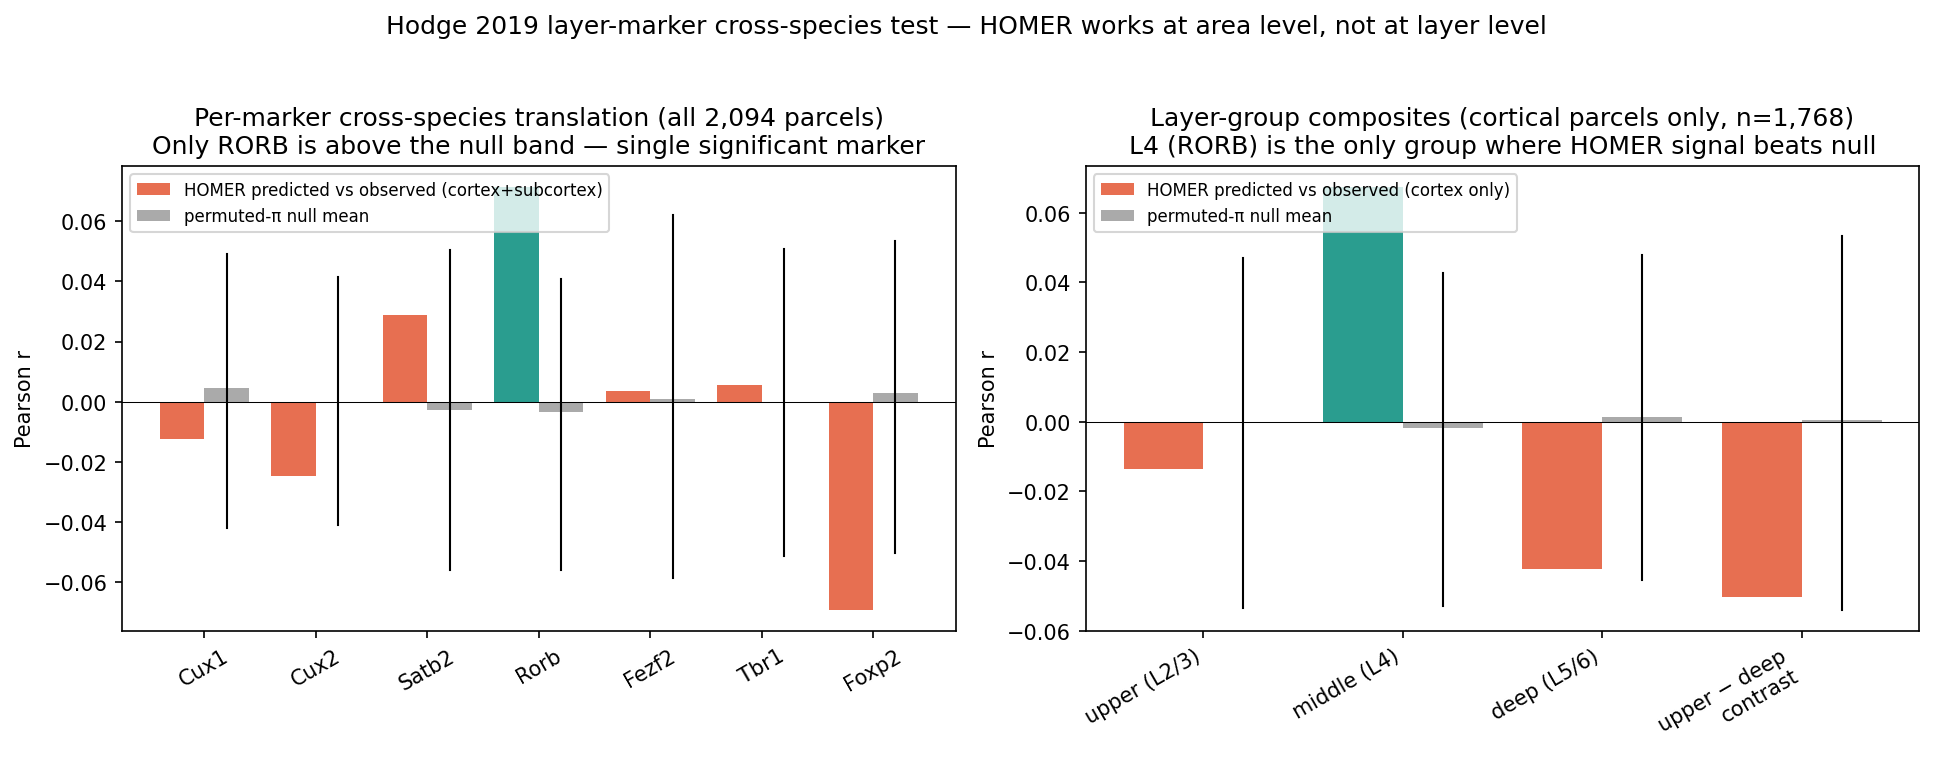

In [5]:
# Show the figure from the standalone plot script
from IPython.display import Image, display
fig_path = ROOT / 'outputs/figures/hodge_2019_layer_markers.png'
if fig_path.exists():
    display(Image(str(fig_path)))
else:
    print('Run experiments/hodge_2019_cortical_layers/03_plot.py to generate the figure.')


## What this tells us about HOMER's resolution

| Test | Result | What it implies |
|---|---|---|
| Per-marker, all 2094 parcels | Only RORB significant (r=+0.07) | Parcel-level layer-marker patterns don't translate |
| Per-layer-group, cortex only | Only L4 significant | Even cortex-restricted, layer markers don't translate |
| upper − deep contrast | Not significant | Laminar contrast doesn't survive π |
| Lobe-aggregated | All positive (r = +0.11 to +0.23) but n=8 underpowered | Broad cortical-gradient patterns may translate |

**Why RORB works**: L4 has area-specific (not just layer-specific) spatial structure — high in V1, S1, A1, low elsewhere. HOMER's anchors strongly bind these primary sensory cortices cross-species, so RORB's area distribution is recoverable through π.

**Why the others don't**: CUX1/2/SATB2/FEZF2/TBR1/FOXP2 have spatial patterns dominated by lamination, which HOMER's parcellation doesn't preserve (parcels mix all 6 layers, anchors are area-level).

**This is a useful negative result** — it establishes a resolution boundary on what HOMER can and can't say. HOMER works at the anatomical-area / network level; it does not translate fine-grained laminar gene expression. If you want layer-level translation, you'd need either (a) a finer parcellation that preserves laminar boundaries (mouse + human cortical-layer-aware atlases like the Hodge cell-type taxonomy), or (b) anchor packs specifying layer-level correspondences.

For full details: [`docs/03_results.md`](../docs/03_results.md).
